In [1]:
import torch
import matplotlib.pyplot as plt
import lightning as L
import mrcfile
from cryosim.ghostbuster import Ghostbuster
from cryosim.cryosparc_utils import extract_parameters_from_csfile
from cryosim.plotting_tools import plot3d
from cryosim.array_utils import ball3d, downsample
from torch.utils.data import DataLoader, TensorDataset

%load_ext autoreload
%autoreload 2

In [2]:
# params
device = 1
return_class = "1"
scattering_model = "rytov"
randomize_phases = False
sparsity = 0
lr = 0.1
symmetry = "I1"  #'I1'
niter = 5
dose_per_angstrom = 22.5

## Import GT

In [3]:
path = "/scratch/loh/joel/empiar-10202/aav2_0788.mrc"
with mrcfile.open(path) as mrc:
    gt = torch.as_tensor((mrc.data).copy())
gt.shape

torch.Size([512, 512, 512])

In [4]:
avgpool = torch.nn.AvgPool3d(2, stride=2)
gt_bin2 = torch.squeeze(avgpool(gt[None, None, ...]))
gt_bin4 = torch.squeeze(avgpool(gt_bin2[None, None, ...]))
gt_bin8 = torch.squeeze(avgpool(gt_bin4[None, None, ...]))

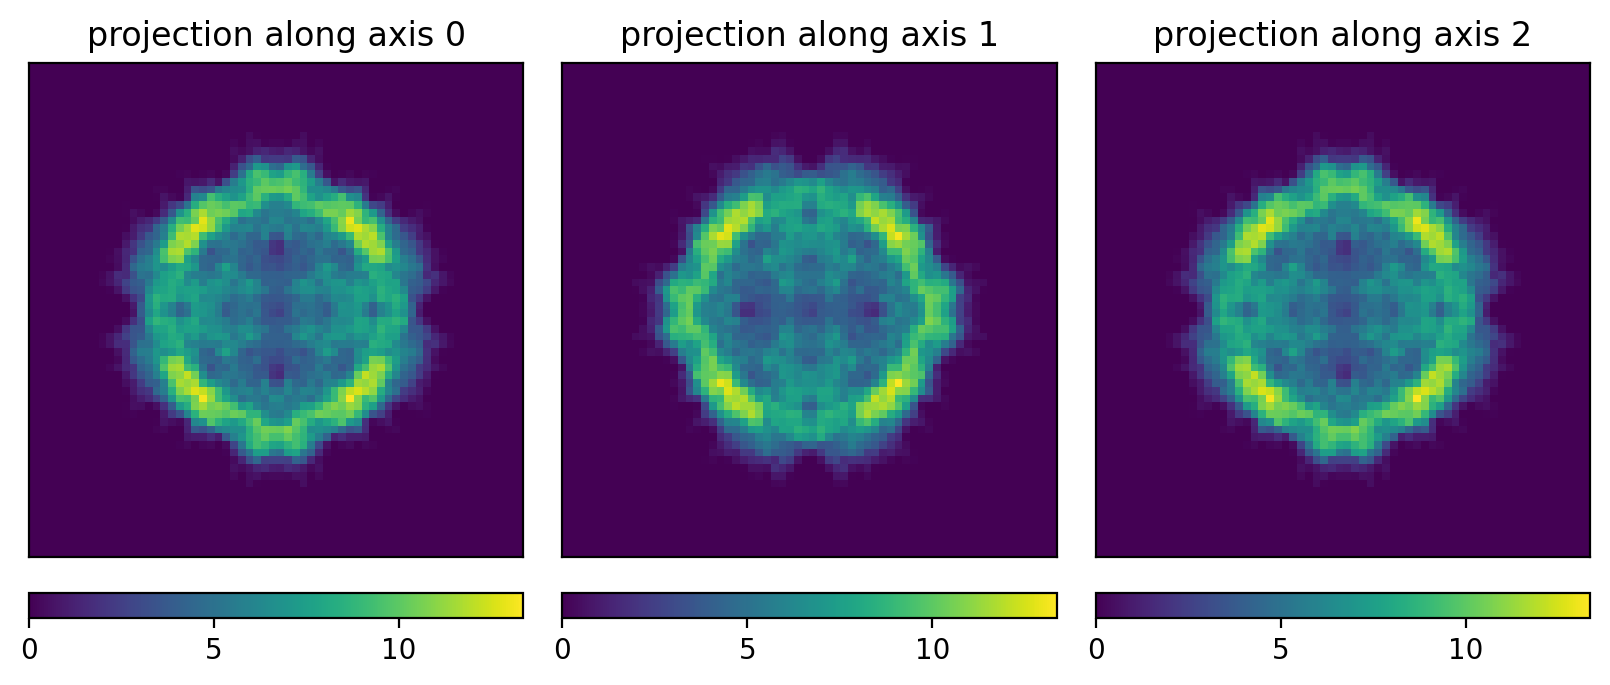

In [5]:
plot3d(gt_bin8)

## Import cryoSPARC

In [6]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_volume_map_half_A.mrc"  # all particles
with mrcfile.open(path) as mrc:
    cryosparc = torch.as_tensor((mrc.data).copy())
cryosparc.shape

torch.Size([512, 512, 512])

In [7]:
cryosparc_bin2 = torch.squeeze(avgpool(cryosparc[None, None, ...]))
cryosparc_bin4 = torch.squeeze(avgpool(cryosparc_bin2[None, None, ...]))
cryosparc_bin8 = torch.squeeze(avgpool(cryosparc_bin4[None, None, ...]))

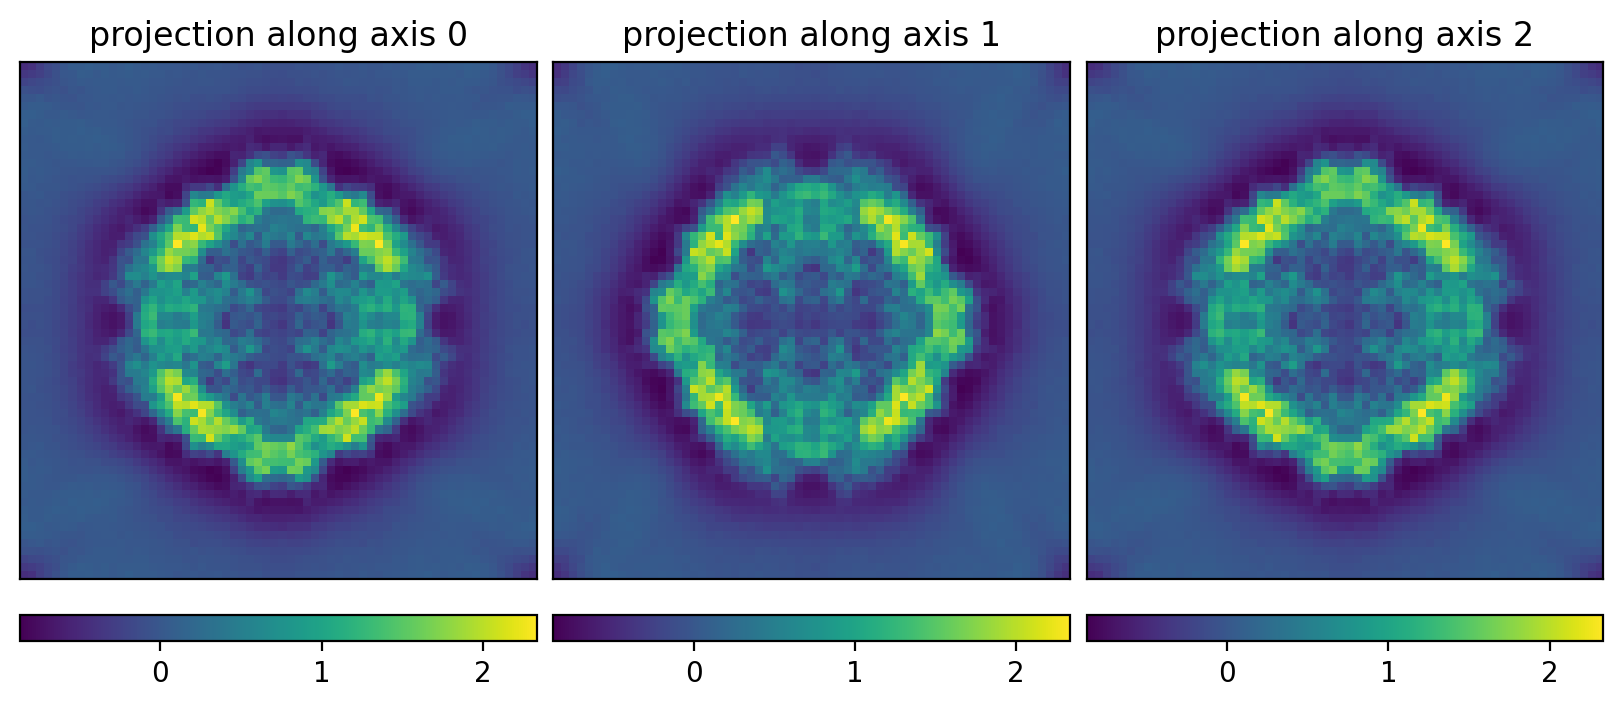

In [8]:
plot3d(cryosparc_bin8)

In [9]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_volume_mask_fsc.mrc"  # all particles
with mrcfile.open(path) as mrc:
    mask = torch.as_tensor((mrc.data).copy())
mask.shape

torch.Size([512, 512, 512])

In [10]:
mask_bin2 = torch.squeeze(avgpool(mask[None, None, ...]))
mask_bin4 = torch.squeeze(avgpool(mask_bin2[None, None, ...]))
mask_bin8 = torch.squeeze(avgpool(mask_bin4[None, None, ...]))

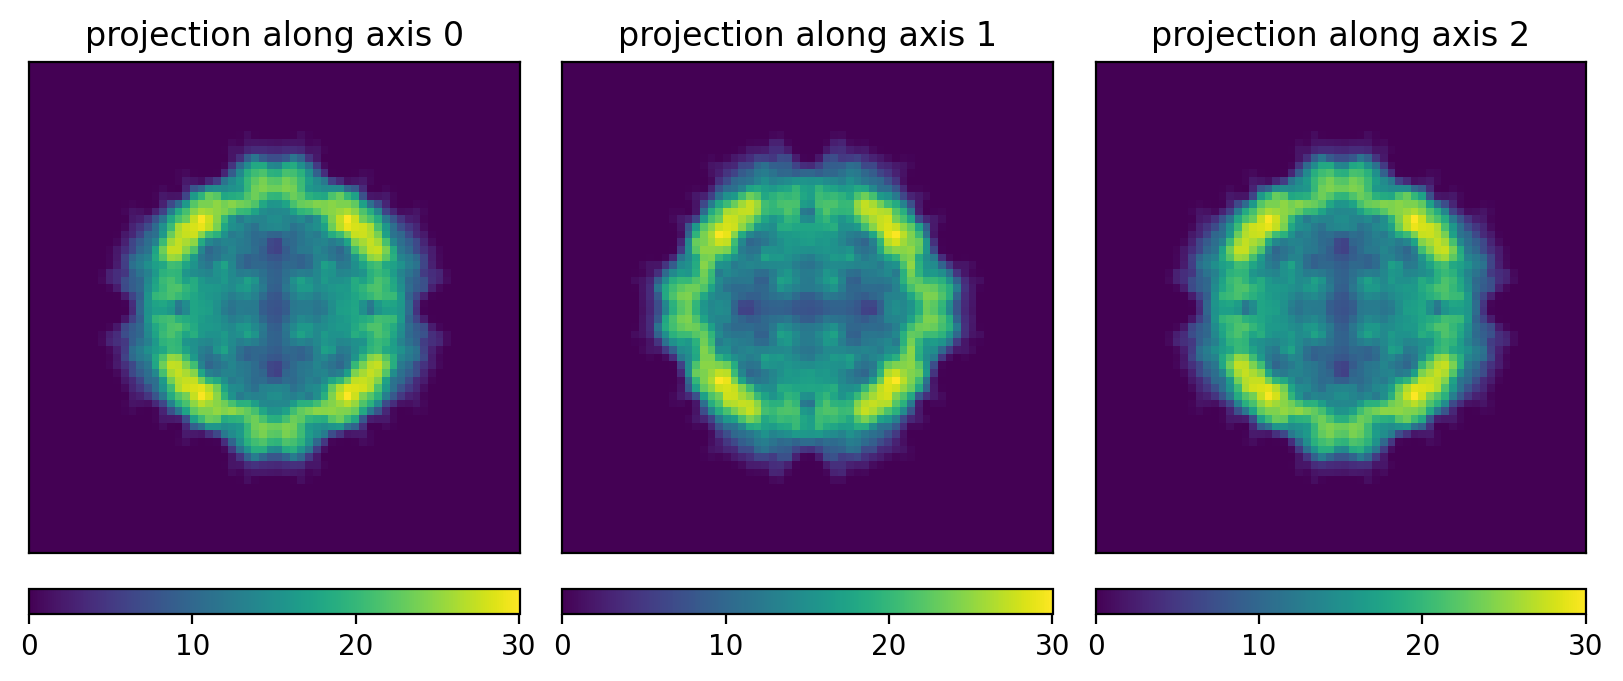

In [11]:
plot3d(mask_bin8)

## Import data

In [12]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_particles.cs"  # all particles
(
    energy,
    orig_pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
) = extract_parameters_from_csfile(path, return_class=return_class)

rotations.shape, translations_A.shape, anisomag.shape

(torch.Size([15257, 4]), torch.Size([15257, 2]), torch.Size([15258, 2, 2]))

In [13]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J247/restack/batch_0_restacked.mrc"  # all particles
with mrcfile.open(path) as mrc:
    images_flip = torch.as_tensor((mrc.data[indices]).copy())
images_flip.shape

torch.Size([15257, 512, 512])

In [14]:
# sign flip data
n = images_flip.shape[-1]
images = -images_flip

In [15]:
# rescale images
dose_per_area = dose_per_angstrom * (orig_pixel_size) ** 2
images = dose_per_area**0.5 * scale[..., None, None] * images + dose_per_area

In [16]:
images_bin8 = downsample(images, bin_factor=8, method="avgpool")
images_bin8.shape

torch.Size([15257, 64, 64])

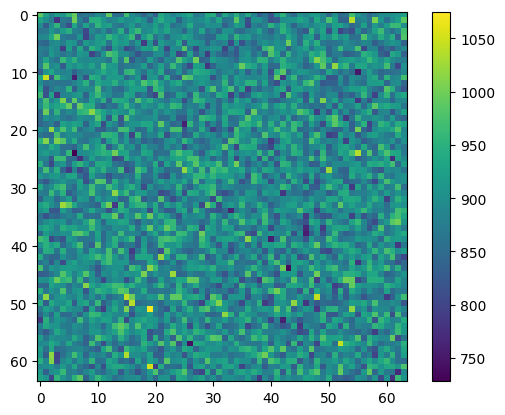

In [17]:
plt.imshow(images_bin8[0])
plt.colorbar()

## 3D reconstruction

In [18]:
klim = None  # or None
positivity = False

params = {
    "lr": lr,
    "symmetry": symmetry,
    "sparsity": sparsity,
    "rotate_mode": "real",
    "flipcurvature": True,
    "symmetry_batchsize": 3,
}

In [19]:
# upsample volume
volume_init = torch.zeros(
    images_bin8.shape[-1], images_bin8.shape[-1], images_bin8.shape[-1]
)

idx = torch.arange(images_bin8.shape[0])
training_dataset = TensorDataset(images_bin8, idx)
train_loader1 = DataLoader(training_dataset, batch_size=3, num_workers=31)

In [20]:
kmask = ball3d(64, 64)

In [21]:
trainer = L.Trainer(
    accelerator="gpu",
    devices=[device],
    max_epochs=niter,
    precision="16-mixed",
)
model1 = Ghostbuster(
    volume_init,
    orig_pixel_size * 8,
    rotations,
    translations_A,
    ctf_params,
    energy,
    dose_per_angstrom,
    anisomag=anisomag,
    alpha=alpha,
    scattering_model=scattering_model,
    # defocus_offset=torch.tensor(30.),
    fsc_ref=gt,
    fsc_mask=mask,
    kmask=kmask,
    **params,
)
# tuner = Tuner(trainer)
# lr_finder1 = tuner.lr_find(model1, train_loader1, min_lr=1e-5, max_lr=1e1)
trainer.fit(model1, train_loader1)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/mnt/cbis/home/e0788253/czii/cryosim/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Output()

Single parameter optimization mode.


You are using a CUDA device ('NVIDIA L40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/mnt/cbis/home/e0788253/czii/cryosim/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | imagegenerator | ImageGenerator | 0      | train
  | other params   | n/a            | 262 K  | n/a  
----------------------------------------------------------
262 K     Trainable params
0         Non-trainable param

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


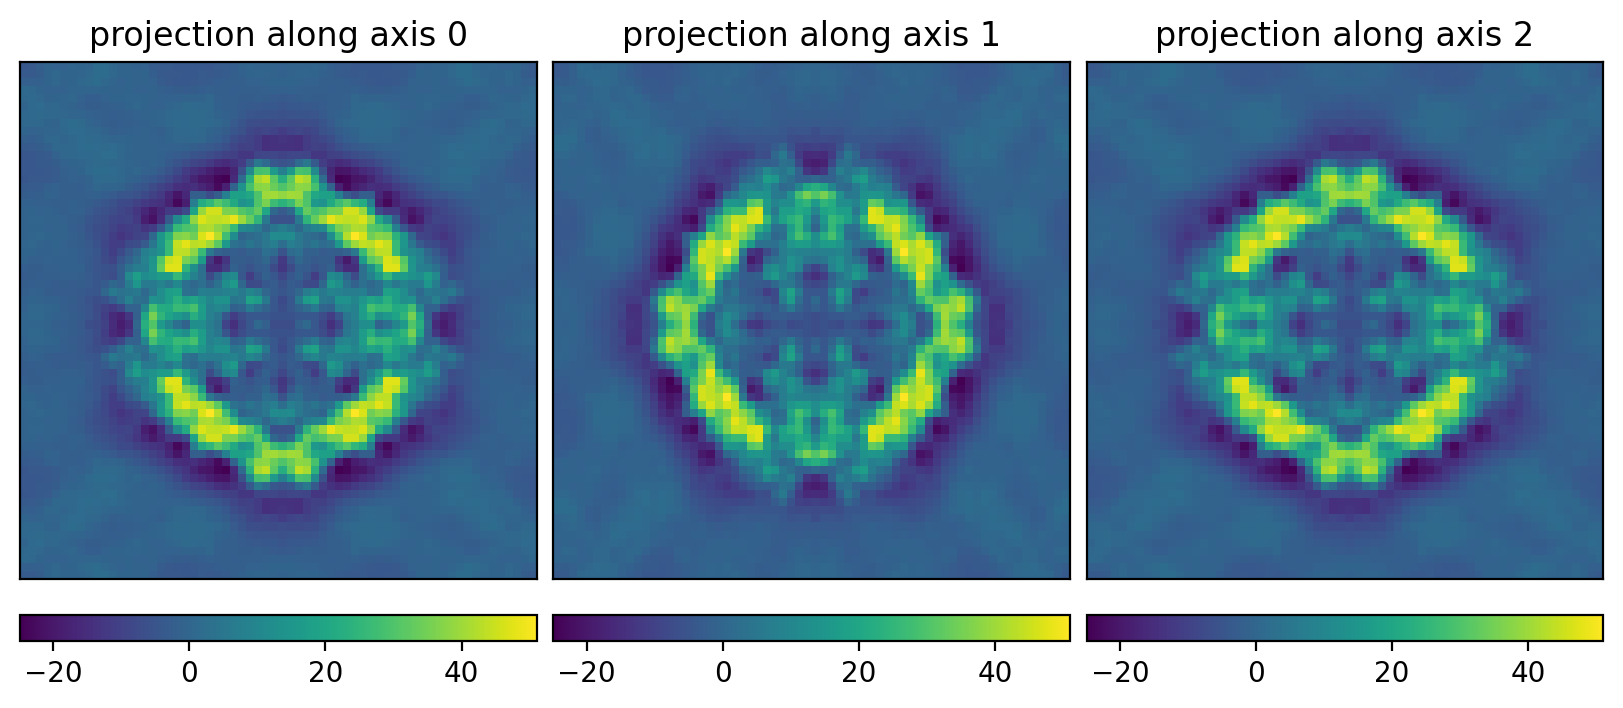

In [22]:
plot3d(model1.V.detach().cpu())